In [6]:
# =========================
# SWINUNETR INFERENCE
# =========================
import torch
import nibabel as nib
import numpy as np
from pathlib import Path
from tqdm import tqdm
from monai.networks.nets import SwinUNETR
from monai.inferers import sliding_window_inference

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

DATA_PATH = Path(r"C:\Users\Admin\Desktop\meghana\Optimized\nnunet_raw\Dataset500_BraTSGlioma\imagesTr")
OUT_PATH  = Path(r"C:\Users\Admin\Desktop\meghana\Optimized\swin_outputs_preds")
MODEL_PATH = r"C:\Users\Admin\Desktop\meghana\Optimized\swin_outputs\swinunetr_brats_final.pth"

OUT_PATH.mkdir(exist_ok=True)

ROI_SIZE = (128, 128, 128)
SW_BATCH_SIZE = 4

from monai.networks.nets import SwinUNETR
import torch

model = SwinUNETR(
    spatial_dims=3,
    in_channels=4,
    out_channels=4,
    feature_size=48,
    use_checkpoint=False
).to(DEVICE)

# ── Load weights ──
ckpt = torch.load(
    r"C:\Users\Admin\Desktop\meghana\Optimized\swin_outputs\swinunetr_brats_final.pth",
    map_location=DEVICE
)

state_dict = ckpt.get("state_dict", ckpt)
state_dict = {k.replace("module.", ""): v for k, v in state_dict.items()}

model.load_state_dict(state_dict)
model.eval()

print("✅ Swin model loaded successfully")

# ── HELPERS ──
def get_case_ids(path):
    return sorted(set([f.name[:-12] for f in path.glob("*_0000.nii.gz")]))

def load_case(case_id):
    imgs = []
    for i in range(4):
        img = nib.load(DATA_PATH / f"{case_id}_{i:04d}.nii.gz").get_fdata()
        imgs.append(img)
    x = np.stack(imgs).astype(np.float32)
    return x

cases = get_case_ids(DATA_PATH)

# ── INFERENCE ──
with torch.no_grad():
    for case_id in tqdm(cases, desc="Swin Inference"):
        x = load_case(case_id)

        # normalization
        for c in range(4):
            x[c] = (x[c] - x[c].mean()) / (x[c].std() + 1e-8)

        x_t = torch.tensor(x).unsqueeze(0).to(DEVICE)

        logits = sliding_window_inference(
            x_t,
            roi_size=ROI_SIZE,
            sw_batch_size=SW_BATCH_SIZE,
            predictor=model,
            overlap=0.5
        )

        pred = torch.argmax(logits, dim=1).squeeze().cpu().numpy().astype(np.uint8)

        nib.save(
            nib.Nifti1Image(pred, np.eye(4)),
            OUT_PATH / f"{case_id}.nii.gz"
        )

print("✅ Swin predictions complete")

c:\Users\Admin\Desktop\meghana\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Swin model loaded successfully


Swin Inference: 100%|██████████| 1350/1350 [1:35:25<00:00,  4.24s/it]

✅ Swin predictions complete


In [7]:
import nibabel as nib
import numpy as np
from pathlib import Path
from tqdm import tqdm

# ── PATHS ──
GT_PATH = Path(r"C:\Users\Admin\Desktop\meghana\Optimized\nnunet_raw\Dataset500_BraTSGlioma\labelsTr")

NNUNET_PRED = Path(r"C:\Users\Admin\Desktop\meghana\Optimized\predictions_test")
SWIN_PRED   = Path(r"C:\Users\Admin\Desktop\meghana\Optimized\swin_outputs_preds")


# ── METRICS ──
def safe_dice(pred, gt):
    if pred.sum() == 0 and gt.sum() == 0:
        return 1.0
    return 2 * (pred & gt).sum() / (pred.sum() + gt.sum() + 1e-5)


def compute_metrics(pred, gt):
    et_pred, et_gt = (pred == 3), (gt == 3)
    tc_pred, tc_gt = ((pred == 1) | (pred == 3)), ((gt == 1) | (gt == 3))
    wt_pred, wt_gt = (pred > 0), (gt > 0)

    return {
        "ET_dice": safe_dice(et_pred, et_gt),
        "TC_dice": safe_dice(tc_pred, tc_gt),
        "WT_dice": safe_dice(wt_pred, wt_gt)
    }


# ── BUILD GT LOOKUP (FAST + SAFE) ──
def build_gt_lookup():
    gt_dict = {}
    for f in GT_PATH.glob("*.nii.gz"):
        key = f.name.replace(".nii.gz", "")
        gt_dict[key] = f
    print(f"📂 GT files indexed: {len(gt_dict)}")
    return gt_dict


# ── EVALUATION ──
def evaluate(pred_path, name, gt_dict):
    files = sorted(pred_path.rglob("*.nii.gz"))
    print(f"\n🔍 {name} files found: {len(files)}")

    if len(files) == 0:
        print("🚨 No prediction files found")
        return None

    # 🔎 SAMPLE DEBUG
    print("\n=== SAMPLE MATCH CHECK ===")
    for f in files[:5]:
        case_id = f.name.replace(".nii.gz", "")
        exists = case_id in gt_dict
        print(f"Pred: {f.name} → GT exists: {exists}")
    print("==========================\n")

    all_metrics = []
    missing_count = 0
    shape_mismatch = 0

    for f in tqdm(files, desc=f"Evaluating {name}"):
        case_id = f.name.replace(".nii.gz", "")

        if case_id not in gt_dict:
            missing_count += 1
            if missing_count <= 5:
                print(f"❌ Missing GT for: {case_id}")
            continue

        gt_file = gt_dict[case_id]

        try:
            pred = nib.load(f).get_fdata()
            gt   = nib.load(gt_file).get_fdata()

            if pred.shape != gt.shape:
                shape_mismatch += 1
                if shape_mismatch <= 5:
                    print(f"⚠️ Shape mismatch: {case_id} → {pred.shape} vs {gt.shape}")
                continue

            all_metrics.append(compute_metrics(pred, gt))

        except Exception as e:
            print(f"❌ Error: {case_id} → {e}")
            continue

    # ── SUMMARY ──
    print(f"\n📊 {name} SUMMARY")
    print(f"Total predictions: {len(files)}")
    print(f"Valid cases: {len(all_metrics)}")
    print(f"Missing GT: {missing_count}")
    print(f"Shape mismatches: {shape_mismatch}")

    if len(all_metrics) == 0:
        print("🚨 STOP: No valid cases → FIX naming or paths")
        return None

    # ── METRIC AGGREGATION ──
    results = {}
    for key in all_metrics[0]:
        vals = [m[key] for m in all_metrics]
        results[key] = (np.mean(vals), np.std(vals))

    print(f"\n📈 {name} RESULTS")
    for k, v in results.items():
        print(f"{k}: {v[0]:.4f} ± {v[1]:.4f}")

    return results


# ── RUN ──
if __name__ == "__main__":
    gt_dict = build_gt_lookup()

    nnunet_results = evaluate(NNUNET_PRED, "nnU-Net", gt_dict)
    swin_results   = evaluate(SWIN_PRED, "SwinUNETR", gt_dict)

📂 GT files indexed: 1350

🔍 nnU-Net files found: 1350

=== SAMPLE MATCH CHECK ===
Pred: BraTS_0000.nii.gz → GT exists: True
Pred: BraTS_0001.nii.gz → GT exists: True
Pred: BraTS_0002.nii.gz → GT exists: True
Pred: BraTS_0003.nii.gz → GT exists: True
Pred: BraTS_0004.nii.gz → GT exists: True



Evaluating nnU-Net: 100%|██████████| 1350/1350 [11:44<00:00,  1.92it/s]



📊 nnU-Net SUMMARY
Total predictions: 1350
Valid cases: 1350
Missing GT: 0
Shape mismatches: 0

📈 nnU-Net RESULTS
ET_dice: 0.8466 ± 0.1778
TC_dice: 0.8632 ± 0.1695
WT_dice: 0.9177 ± 0.0680

🔍 SwinUNETR files found: 1350

=== SAMPLE MATCH CHECK ===
Pred: BraTS_0000.nii.gz → GT exists: True
Pred: BraTS_0001.nii.gz → GT exists: True
Pred: BraTS_0002.nii.gz → GT exists: True
Pred: BraTS_0003.nii.gz → GT exists: True
Pred: BraTS_0004.nii.gz → GT exists: True



Evaluating SwinUNETR: 100%|██████████| 1350/1350 [11:36<00:00,  1.94it/s]


📊 SwinUNETR SUMMARY
Total predictions: 1350
Valid cases: 1350
Missing GT: 0
Shape mismatches: 0

📈 SwinUNETR RESULTS
ET_dice: 0.0303 ± 0.0466
TC_dice: 0.0322 ± 0.0476
WT_dice: 0.0612 ± 0.0569


In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns
import nibabel as nib
from tqdm import tqdm

def compute_confusion_matrix(pred_path, gt_dict):
    y_true = []
    y_pred = []

    files = list(pred_path.rglob("*.nii.gz"))

    for f in tqdm(files, desc="Building Confusion Matrix"):
        case_id = f.name.replace(".nii.gz", "")
        if case_id not in gt_dict:
            continue

        pred = np.asarray(nib.load(f).dataobj, dtype=np.uint8).flatten()
        gt   = np.asarray(nib.load(gt_dict[case_id]).dataobj, dtype=np.uint8).flatten()

        y_true.extend(gt)
        y_pred.extend(pred)

    cm = confusion_matrix(y_true, y_pred, labels=[0,1,2,3])
    return cm


def plot_confusion_matrix(cm):
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["BG","NCR","ED","ET"],
                yticklabels=["BG","NCR","ED","ET"])
    plt.xlabel("Predicted")
    plt.ylabel("Ground Truth")
    plt.title("Voxel-wise Confusion Matrix")
    plt.show()

In [10]:
def plot_dice_distribution(all_metrics, model_name):
    import matplotlib.pyplot as plt

    for key in ["ET_dice", "TC_dice", "WT_dice"]:
        vals = [m[key] for m in all_metrics]

        plt.hist(vals, bins=30)
        plt.title(f"{model_name} - {key} Distribution")
        plt.xlabel("Dice Score")
        plt.ylabel("Frequency")
        plt.show()

In [11]:
def compare_models(nnunet_metrics, swin_metrics):
    import matplotlib.pyplot as plt

    keys = ["ET_dice", "TC_dice", "WT_dice"]

    nn_means = [np.mean([m[k] for m in nnunet_metrics]) for k in keys]
    sw_means = [np.mean([m[k] for m in swin_metrics]) for k in keys]

    x = np.arange(len(keys))

    plt.bar(x - 0.2, nn_means, width=0.4, label="nnU-Net")
    plt.bar(x + 0.2, sw_means, width=0.4, label="SwinUNETR")

    plt.xticks(x, keys)
    plt.ylabel("Dice Score")
    plt.title("Model Comparison")
    plt.legend()
    plt.show()

In [12]:
def visualize_prediction(case_id, pred_path, gt_dict):
    import matplotlib.pyplot as plt

    pred = np.asarray(nib.load(pred_path / f"{case_id}.nii.gz").dataobj)
    gt   = np.asarray(nib.load(gt_dict[case_id]).dataobj)

    slice_idx = pred.shape[2] // 2

    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    plt.imshow(gt[:,:,slice_idx], cmap="gray")
    plt.title("Ground Truth")

    plt.subplot(1,3,2)
    plt.imshow(pred[:,:,slice_idx], cmap="gray")
    plt.title("Prediction")

    plt.subplot(1,3,3)
    plt.imshow(gt[:,:,slice_idx] != pred[:,:,slice_idx], cmap="hot")
    plt.title("Error Map")

    plt.show()

Fast Confusion Matrix: 100%|██████████| 1350/1350 [21:04<00:00,  1.07it/s]


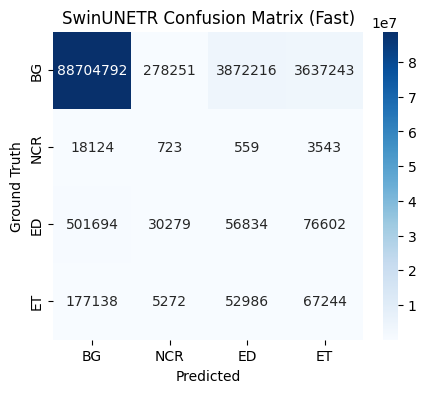

Fast Class Dist: 100%|██████████| 50/50 [00:12<00:00,  3.92it/s]


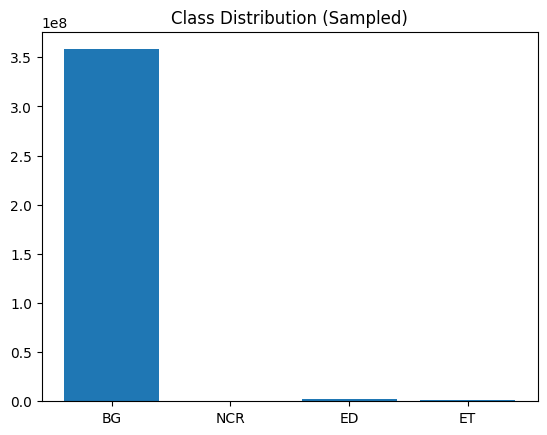

Sample: BraTS_0000


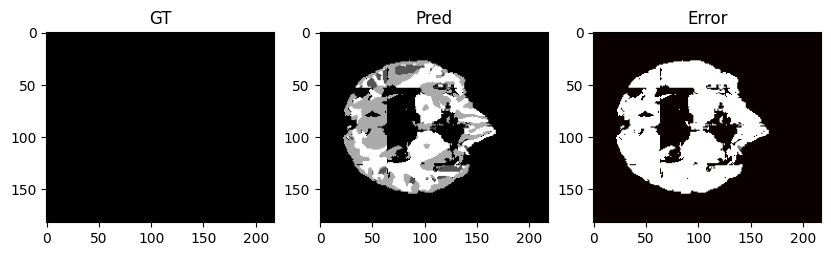

In [15]:
# =========================
# FAST + MEMORY SAFE VISUALIZATION
# =========================
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nibabel as nib
from tqdm import tqdm

# ── FAST CONFUSION MATRIX (STREAMING) ──
def fast_confusion_matrix(pred_path, gt_dict, sample_rate=0.01):
    cm = np.zeros((4,4), dtype=np.int64)
    files = list(pred_path.rglob("*.nii.gz"))

    for f in tqdm(files, desc="Fast Confusion Matrix"):
        case_id = f.name.replace(".nii.gz", "")
        if case_id not in gt_dict:
            continue

        pred = np.asarray(nib.load(f).dataobj, dtype=np.uint8).flatten()
        gt   = np.asarray(nib.load(gt_dict[case_id]).dataobj, dtype=np.uint8).flatten()

        # 🔥 SAMPLE (critical for speed)
        idx = np.random.choice(len(gt), int(len(gt)*sample_rate), replace=False)

        for p, g in zip(pred[idx], gt[idx]):
            if g < 4 and p < 4:
                cm[g, p] += 1

    return cm


def plot_cm(cm, title):
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["BG","NCR","ED","ET"],
                yticklabels=["BG","NCR","ED","ET"])
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Ground Truth")
    plt.show()


# ── FAST CLASS DISTRIBUTION (SAMPLED) ──
def fast_class_distribution(gt_dict, max_cases=100):
    counts = np.zeros(4)
    files = list(gt_dict.values())[:max_cases]

    for f in tqdm(files, desc="Fast Class Dist"):
        gt = np.asarray(nib.load(f).dataobj, dtype=np.uint8)

        for i in range(4):
            counts[i] += np.sum(gt == i)

    plt.figure()
    plt.bar(["BG","NCR","ED","ET"], counts)
    plt.title("Class Distribution (Sampled)")
    plt.show()


# ── QUICK VISUALIZATION (1 CASE ONLY) ──
def quick_visual(case_id, pred_path, gt_dict):
    pred = np.asarray(nib.load(pred_path / f"{case_id}.nii.gz").dataobj)
    gt   = np.asarray(nib.load(gt_dict[case_id]).dataobj)

    z = pred.shape[2] // 2

    plt.figure(figsize=(10,3))

    plt.subplot(1,3,1)
    plt.imshow(gt[:,:,z], cmap="gray")
    plt.title("GT")

    plt.subplot(1,3,2)
    plt.imshow(pred[:,:,z], cmap="gray")
    plt.title("Pred")

    plt.subplot(1,3,3)
    plt.imshow(gt[:,:,z] != pred[:,:,z], cmap="hot")
    plt.title("Error")

    plt.show()


# =========================
# RUN FAST
# =========================

# ⚡ Confusion Matrix (FAST)
cm_sw = fast_confusion_matrix(SWIN_PRED, gt_dict, sample_rate=0.01)
plot_cm(cm_sw, "SwinUNETR Confusion Matrix (Fast)")

# ⚡ Class Distribution (FAST)
fast_class_distribution(gt_dict, max_cases=50)

# ⚡ One quick visualization
sample_case = list(gt_dict.keys())[0]
print("Sample:", sample_case)
quick_visual(sample_case, SWIN_PRED, gt_dict)